## Import packages

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [13]:
data=pd.read_excel("fertilizer_synthetic_dataset.xlsx")
data.head()

,County,Gender,Age,Education,Farm_Size,Experience,Pricing_Q1,Pricing_Q2,Pricing_Q3,Pricing_Q4,...,Targeting_Q2,Targeting_Q3,Targeting_Q4,Targeting_Q5,Uptake_Q1,Uptake_Q2,Uptake_Q3,Uptake_Q4,Uptake_Q5,Uptake_Index
0,Nakuru,Male,31–40,College,>6 acres,11–15 yrs,2,4,3,5,...,5,3,3,5,5,1,3,4,2,3.83
1,Nakuru,Female,31–40,College,<1 acre,6–10 yrs,2,5,3,5,...,4,5,5,3,3,4,1,1,3,2.59
2,Nakuru,Male,Below 30,Primary,1–3 acres,6–10 yrs,5,5,4,1,...,3,5,5,2,5,5,5,2,4,4.52
3,Nakuru,Male,31–40,Secondary,1–3 acres,11–15 yrs,5,4,4,2,...,1,5,3,4,5,3,5,4,4,3.57
4,Nakuru,Male,41–50,Secondary,1–3 acres,6–10 yrs,4,4,4,3,...,3,3,5,4,5,3,2,4,1,3.06


## Response Rate

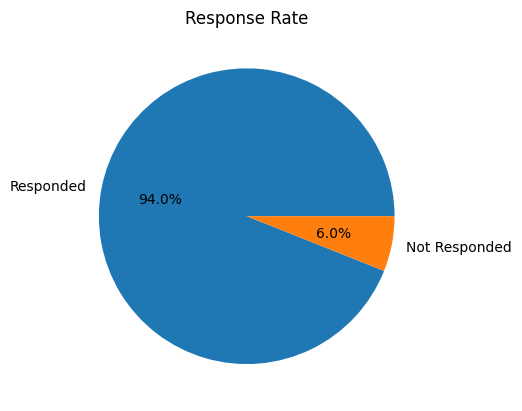

In [3]:
# Data
labels = ['Responded', 'Not Responded']
sizes = [265, 17]

# Plot
plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Response Rate')
plt.show()

## Cronbach’s Alpha

In [10]:
def cronbach_alpha(df):
    df = df.dropna()  # remove missing values if any
    k = df.shape[1]   # number of items
    variance_sum = df.var(ddof=1).sum()
    total_var = df.sum(axis=1).var(ddof=1)
    
    alpha = (k / (k - 1)) * (1 - (variance_sum / total_var))
    return alpha

In [14]:
pricing_cols = [f"Pricing_Q{i}" for i in range(1,6)]
alpha_pricing = cronbach_alpha(data[pricing_cols])
print("Pricing Alpha:", round(alpha_pricing, 3))

Pricing Alpha: -0.05


In [15]:
distribution_cols = [f"Distribution_Q{i}" for i in range(1,6)]
alpha_distribution = cronbach_alpha(data[distribution_cols])
print("Distribution Alpha:", round(alpha_distribution, 3))

Distribution Alpha: 0.037


In [16]:
targeting_cols = [f"Targeting_Q{i}" for i in range(1,6)]
alpha_targeting = cronbach_alpha(data[targeting_cols])
print("Targeting Alpha:", round(alpha_targeting, 3))

Targeting Alpha: 0.142


In [17]:
uptake_cols = [f"Uptake_Q{i}" for i in range(1,6)]
alpha_uptake = cronbach_alpha(data[uptake_cols])
print("Uptake Alpha:", round(alpha_uptake, 3))

Uptake Alpha: -0.179


## Frequencies and Distributions 

### Gender

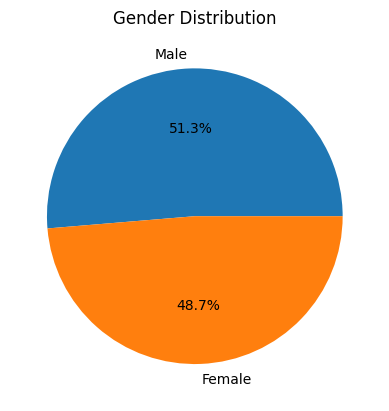

In [18]:
data['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

### Age Analysis

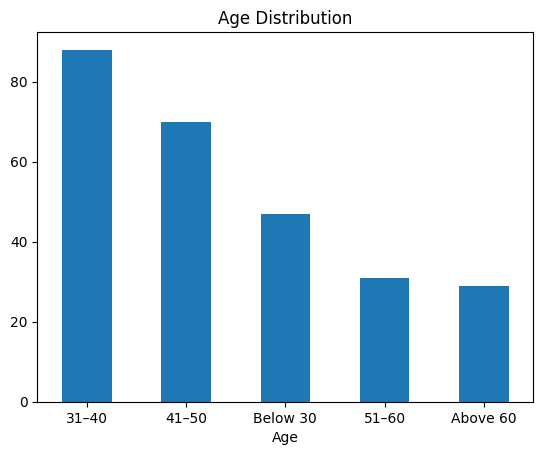

In [27]:
data['Age'].value_counts().plot.bar()
plt.title("Age Distribution")
plt.xticks(rotation=0)
plt.show()

### County 

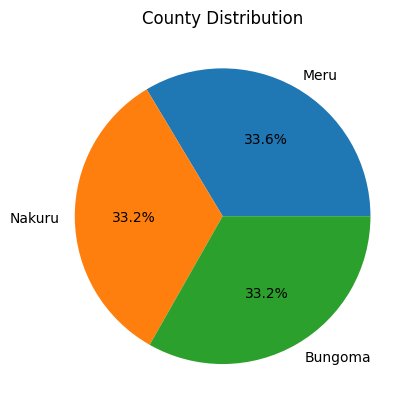

In [20]:
data['County'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("County Distribution")
plt.ylabel("")
plt.show()

### Education 

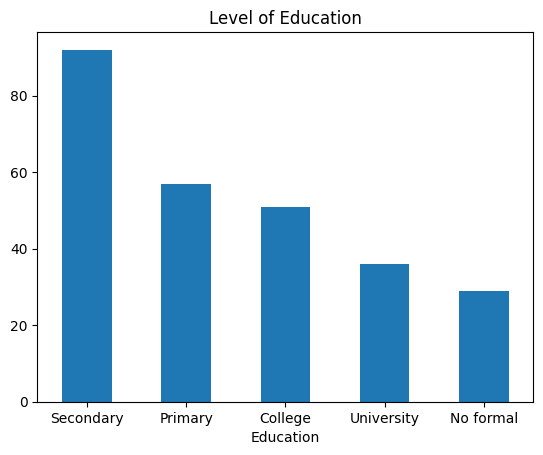

In [26]:
data['Education'].value_counts().plot.bar()
plt.title("Level of Education")
plt.xticks(rotation=0)
plt.show()

### Farm Size 

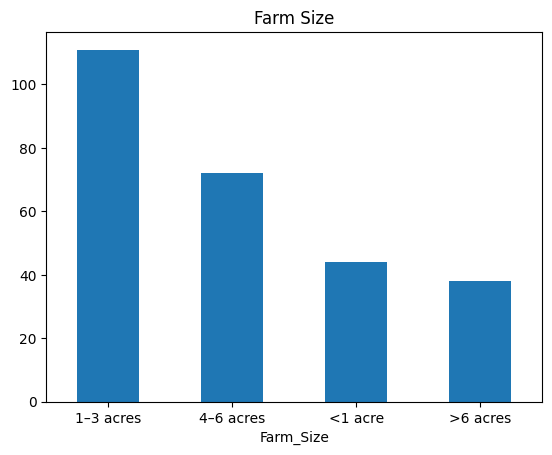

In [25]:
data['Farm_Size'].value_counts().plot.bar()
plt.title("Farm Size")
plt.xticks(rotation=0)
plt.show()

### Years of Experience 

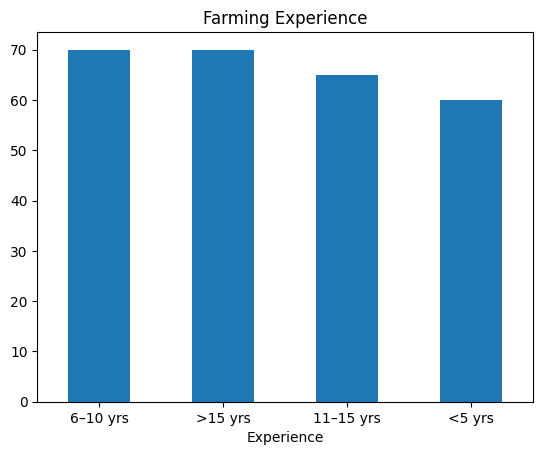

In [24]:
data['Experience'].value_counts().plot.bar()
plt.title("Farming Experience")
plt.xticks(rotation=0)
plt.show()

## Descriptive Analysis 


---------------------------------------------
### PRICING REFORMS DESCRIPTIVE STATISTICS
---------------------------------------------

In [34]:
# ---------------------------------------------
# PRICING REFORMS DESCRIPTIVE STATISTICS
# ---------------------------------------------

# Questionnaire items
pricing_items = {
    "Subsidized fertilizer prices are lower than market prices.": "Pricing_Q1",
    "Government fertilizer price discounts encourage farmers to buy fertilizer.": "Pricing_Q2",
    "Price subsidies reduce the financial burden of fertilizer purchase.": "Pricing_Q3",
    "Lower fertilizer prices increase farmers’ willingness to use fertilizer.": "Pricing_Q4",
    "Price discounts influence my decision to apply fertilizer.": "Pricing_Q5"
}

# Create descriptive statistics table
pricing_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

# Compute statistics
for statement, column in pricing_items.items():
    pricing_desc.loc[len(pricing_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

# Display results
print("\nFERTILIZER PRICE DISCOUNT")
print(pricing_desc)

# ---------------------------------------------
# PERCEIVED AFFORDABILITY
# ---------------------------------------------

affordability_items = {
    "Fertilizer under the subsidy program is affordable to smallholder farmers.": "Pricing_Q1",
    "The current subsidy price allows farmers to purchase sufficient fertilizer.": "Pricing_Q2",
    "Fertilizer affordability affects farmers’ fertilizer application decisions.": "Pricing_Q3",
    "Farmers are more likely to purchase fertilizer when prices are affordable.": "Pricing_Q4",
    "Affordable fertilizer improves farming productivity.": "Pricing_Q5"
}

affordability_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in affordability_items.items():
    affordability_desc.loc[len(affordability_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nPERCEIVED AFFORDABILITY")
print(affordability_desc)

# ---------------------------------------------
# DISBURSEMENT TIME LAG
# ---------------------------------------------

disbursement_items = {
    "Fertilizer subsidies are distributed before the planting season.": "Pricing_Q1",
    "Delays in subsidy distribution affect fertilizer usage.": "Pricing_Q2",
    "Farmers receive fertilizer in time to apply during planting.": "Pricing_Q3",
    "Timely fertilizer distribution encourages fertilizer uptake.": "Pricing_Q4",
    "Delayed fertilizer delivery reduces fertilizer application.": "Pricing_Q5"
}

disbursement_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in disbursement_items.items():
    disbursement_desc.loc[len(disbursement_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nDISBURSEMENT TIME LAG")
print(disbursement_desc)

# ---------------------------------------------
# OPTIONAL EXPORT TO EXCEL
# ---------------------------------------------

with pd.ExcelWriter("pricing_descriptive_statistics.xlsx") as writer:
    pricing_desc.to_excel(writer, sheet_name="Price_Discount", index=False)
    affordability_desc.to_excel(writer, sheet_name="Affordability", index=False)
    disbursement_desc.to_excel(writer, sheet_name="Disbursement", index=False)

print("\nDescriptive statistics exported successfully.")


FERTILIZER PRICE DISCOUNT
                                           Statement   Mean  Variance  \
0  Subsidized fertilizer prices are lower than ma...  3.645     1.192   
1  Government fertilizer price discounts encourag...  3.683     1.066   
2  Price subsidies reduce the financial burden of...  3.626     1.189   
3  Lower fertilizer prices increase farmers’ will...  3.570     1.360   
4  Price discounts influence my decision to apply...  3.653     1.311   

   Std Deviation  
0          1.092  
1          1.032  
2          1.091  
3          1.166  
4          1.145  

PERCEIVED AFFORDABILITY
                                           Statement   Mean  Variance  \
0  Fertilizer under the subsidy program is afford...  3.645     1.192   
1  The current subsidy price allows farmers to pu...  3.683     1.066   
2  Fertilizer affordability affects farmers’ fert...  3.626     1.189   
3  Farmers are more likely to purchase fertilizer...  3.570     1.360   
4  Affordable fertilizer impro

---------------------------------------------
### DISTRIBUTION MODEL CHANGES DESCRIPTIVE STATISTICS
---------------------------------------------

In [35]:
# -----------------------------------------------------
# DISTANCE TO OUTLET
# -----------------------------------------------------

distance_items = {
    "Fertilizer distribution centers are located near farmers.": "Distribution_Q1",
    "Long travel distance discourages farmers from purchasing fertilizer.": "Distribution_Q2",
    "Transport costs affect farmers’ uptake of fertilizer.": "Distribution_Q3",
    "Farmers located far from distribution centers buy less fertilizer.": "Distribution_Q4",
    "Distance to fertilizer outlets influences fertilizer uptake.": "Distribution_Q5"
}

distance_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in distance_items.items():
    distance_desc.loc[len(distance_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nDISTANCE TO OUTLET")
print(distance_desc)

# -----------------------------------------------------
# OUTLET DENSITY
# -----------------------------------------------------

outlet_items = {
    "There are enough fertilizer outlets in my area.": "Distribution_Q1",
    "Having many fertilizer suppliers improves uptake of fertilizer.": "Distribution_Q2",
    "Farmers easily obtain fertilizer due to availability of many outlets.": "Distribution_Q3",
    "Limited fertilizer outlets reduce fertilizer availability.": "Distribution_Q4",
    "Increased fertilizer outlets would improve fertilizer uptake.": "Distribution_Q5"
}

outlet_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in outlet_items.items():
    outlet_desc.loc[len(outlet_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nOUTLET DENSITY")
print(outlet_desc)

# -----------------------------------------------------
# SUPPLY CONSISTENCY
# -----------------------------------------------------

supply_items = {
    "Fertilizer is consistently available at distribution centers.": "Distribution_Q1",
    "Farmers experience fertilizer shortages during planting seasons.": "Distribution_Q2",
    "Reliable fertilizer supply encourages farmers to apply fertilizer.": "Distribution_Q3",
    "Fertilizer availability influences farmers’ fertilizer use decisions.": "Distribution_Q4",
    "Inconsistent fertilizer supply discourages fertilizer application.": "Distribution_Q5"
}

supply_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in supply_items.items():
    supply_desc.loc[len(supply_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nSUPPLY CONSISTENCY")
print(supply_desc)

# -----------------------------------------------------
# EXPORT RESULTS TO EXCEL
# -----------------------------------------------------

with pd.ExcelWriter("distribution_descriptive_statistics.xlsx") as writer:
    distance_desc.to_excel(writer, sheet_name="Distance_to_Outlet", index=False)
    outlet_desc.to_excel(writer, sheet_name="Outlet_Density", index=False)
    supply_desc.to_excel(writer, sheet_name="Supply_Consistency", index=False)

print("\nDistribution descriptive statistics exported successfully.")


DISTANCE TO OUTLET
                                           Statement   Mean  Variance  \
0  Fertilizer distribution centers are located ne...  3.709     1.268   
1  Long travel distance discourages farmers from ...  3.683     1.323   
2  Transport costs affect farmers’ uptake of fert...  3.721     1.164   
3  Farmers located far from distribution centers ...  3.706     1.224   
4  Distance to fertilizer outlets influences fert...  3.717     1.166   

   Std Deviation  
0          1.126  
1          1.150  
2          1.079  
3          1.106  
4          1.080  

OUTLET DENSITY
                                           Statement   Mean  Variance  \
0    There are enough fertilizer outlets in my area.  3.709     1.268   
1  Having many fertilizer suppliers improves upta...  3.683     1.323   
2  Farmers easily obtain fertilizer due to availa...  3.721     1.164   
3  Limited fertilizer outlets reduce fertilizer a...  3.706     1.224   
4  Increased fertilizer outlets would improve 

---------------------------------------------
### REVISED TARGETING CRITERIA DESCRIPTIVE STATISTICS
---------------------------------------------

In [36]:
# -----------------------------------------------------
# REGISTRATION STATUS
# -----------------------------------------------------

registration_items = {
    "Farmer registration improves uptake of fertilizer subsidies.": "Targeting_Q1",
    "Registered farmers receive fertilizer subsidies more easily.": "Targeting_Q2",
    "The digital registration system improves subsidy transparency.": "Targeting_Q3",
    "The registration process is simple and accessible to farmers.": "Targeting_Q4",
    "Unregistered farmers find it difficult to access fertilizer subsidies.": "Targeting_Q5"
}

registration_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in registration_items.items():
    registration_desc.loc[len(registration_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nREGISTRATION STATUS")
print(registration_desc)

# -----------------------------------------------------
# VOUCHER RECEIPT TIMING
# -----------------------------------------------------

voucher_items = {
    "Farmers receive subsidy vouchers before the planting season.": "Targeting_Q1",
    "Late voucher distribution reduces fertilizer usage.": "Targeting_Q2",
    "Early voucher distribution improves fertilizer redemption.": "Targeting_Q3",
    "Voucher timing influences farmers’ fertilizer purchase decisions.": "Targeting_Q4",
    "Receiving vouchers early increases fertilizer application.": "Targeting_Q5"
}

voucher_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in voucher_items.items():
    voucher_desc.loc[len(voucher_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nVOUCHER RECEIPT TIMING")
print(voucher_desc)

# -----------------------------------------------------
# REDEMPTION FREQUENCY
# -----------------------------------------------------

redemption_items = {
    "Farmers redeem fertilizer vouchers regularly during planting seasons.": "Targeting_Q1",
    "Frequent voucher redemption increases fertilizer usage.": "Targeting_Q2",
    "Farmers who redeem vouchers often apply fertilizer more consistently.": "Targeting_Q3",
    "Regular participation in the subsidy program improves fertilizer adoption.": "Targeting_Q4",
    "Farmers redeem vouchers whenever fertilizer subsidies are available.": "Targeting_Q5"
}

redemption_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

for statement, column in redemption_items.items():
    redemption_desc.loc[len(redemption_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

print("\nREDEMPTION FREQUENCY")
print(redemption_desc)

# -----------------------------------------------------
# EXPORT RESULTS TO EXCEL
# -----------------------------------------------------

with pd.ExcelWriter("targeting_descriptive_statistics.xlsx") as writer:
    registration_desc.to_excel(writer, sheet_name="Registration_Status", index=False)
    voucher_desc.to_excel(writer, sheet_name="Voucher_Timing", index=False)
    redemption_desc.to_excel(writer, sheet_name="Redemption_Frequency", index=False)

print("\nTargeting descriptive statistics exported successfully.")


REGISTRATION STATUS
                                           Statement   Mean  Variance  \
0  Farmer registration improves uptake of fertili...  3.517     1.281   
1  Registered farmers receive fertilizer subsidie...  3.630     1.325   
2  The digital registration system improves subsi...  3.506     1.304   
3  The registration process is simple and accessi...  3.774     1.123   
4  Unregistered farmers find it difficult to acce...  3.596     1.105   

   Std Deviation  
0          1.132  
1          1.151  
2          1.142  
3          1.060  
4          1.051  

VOUCHER RECEIPT TIMING
                                           Statement   Mean  Variance  \
0  Farmers receive subsidy vouchers before the pl...  3.517     1.281   
1  Late voucher distribution reduces fertilizer u...  3.630     1.325   
2  Early voucher distribution improves fertilizer...  3.506     1.304   
3  Voucher timing influences farmers’ fertilizer ...  3.774     1.123   
4  Receiving vouchers early increases

---------------------------------------------
### SMALLHOLDER FARMERS’ UPTAKE OF FERTILIZERS DESCRIPTIVE STATISTICS
---------------------------------------------

In [37]:
# -----------------------------------------------------
# SMALLHOLDER FARMERS’ ACCESS
# -----------------------------------------------------

access_items = {
    "Farmers use fertilizer more frequently under the subsidy program.": "Uptake_Q1",
    "The subsidy program has increased the quantity of fertilizer used by farmers.": "Uptake_Q2",
    "Farmers apply fertilizer more consistently during planting seasons due to the subsidy program.": "Uptake_Q3",
    "Fertilizer subsidies have improved the level of fertilizer application on farms.": "Uptake_Q4",
    "Farmers are more likely to use fertilizer because of the subsidy program.": "Uptake_Q5"
}

access_desc = pd.DataFrame(columns=[
    "Statement",
    "Mean",
    "Variance",
    "Std Deviation"
])

# Compute descriptive statistics
for statement, column in access_items.items():
    access_desc.loc[len(access_desc)] = [
        statement,
        round(data[column].mean(), 3),
        round(data[column].var(), 3),
        round(data[column].std(), 3)
    ]

# Display results
print("\nSMALLHOLDER FARMERS’ ACCESS")
print(access_desc)

# -----------------------------------------------------
# EXPORT RESULTS TO EXCEL
# -----------------------------------------------------

access_desc.to_excel(
    "smallholder_access_descriptive_statistics.xlsx",
    index=False
)

print("\nSmallholder farmers’ access descriptive statistics exported successfully.")


SMALLHOLDER FARMERS’ ACCESS
                                           Statement   Mean  Variance  \
0  Farmers use fertilizer more frequently under t...  3.566     1.383   
1  The subsidy program has increased the quantity...  3.683     1.217   
2  Farmers apply fertilizer more consistently dur...  3.517     1.364   
3  Fertilizer subsidies have improved the level o...  3.558     1.323   
4  Farmers are more likely to use fertilizer beca...  3.679     1.090   

   Std Deviation  
0          1.176  
1          1.103  
2          1.168  
3          1.150  
4          1.044  

Smallholder farmers’ access descriptive statistics exported successfully.


## Correlation Matrix 


CORRELATION MATRIX
                            Pricing_Reforms  Distribution_Model_Changes  \
Pricing_Reforms                       1.000                      -0.016   
Distribution_Model_Changes           -0.016                       1.000   
Revised_Targeting_Criteria            0.066                      -0.136   
Uptake_Of_Fertilizers                 0.068                      -0.051   

                            Revised_Targeting_Criteria  Uptake_Of_Fertilizers  
Pricing_Reforms                                  0.066                  0.068  
Distribution_Model_Changes                      -0.136                 -0.051  
Revised_Targeting_Criteria                       1.000                 -0.002  
Uptake_Of_Fertilizers                           -0.002                  1.000  


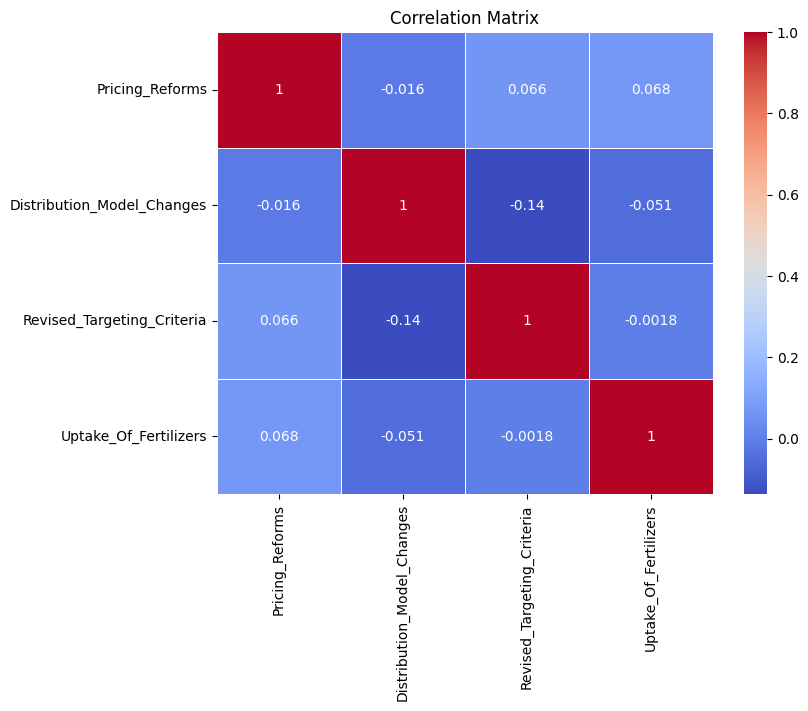

In [41]:
# ---------------------------------------------------
# CREATE COMPOSITE VARIABLES
# ---------------------------------------------------

# Pricing Reforms
pricing_cols = [f"Pricing_Q{i}" for i in range(1,6)]
data['Pricing_Reforms'] = data[pricing_cols].mean(axis=1)

# Distribution Model Changes
distribution_cols = [f"Distribution_Q{i}" for i in range(1,6)]
data['Distribution_Model_Changes'] = data[distribution_cols].mean(axis=1)

# Revised Targeting Criteria
targeting_cols = [f"Targeting_Q{i}" for i in range(1,6)]
data['Revised_Targeting_Criteria'] = data[targeting_cols].mean(axis=1)

# Smallholder Farmers’ Uptake
uptake_cols = [f"Uptake_Q{i}" for i in range(1,6)]
data['Uptake_Of_Fertilizers'] = data[uptake_cols].mean(axis=1)

# ---------------------------------------------------
# CORRELATION MATRIX
# ---------------------------------------------------

corr_variables = data[
    ['Pricing_Reforms',
     'Distribution_Model_Changes',
     'Revised_Targeting_Criteria',
     'Uptake_Of_Fertilizers']
]

correlation_matrix = corr_variables.corr(method='pearson')

# Display matrix
print("\nCORRELATION MATRIX")
print(correlation_matrix.round(3))

# ---------------------------------------------------
# HEATMAP VISUALIZATION
# ---------------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## Multiple Regression Analysis

In [46]:
# ---------------------------------------------------
# CREATE COMPOSITE VARIABLES
# ---------------------------------------------------

# Pricing Reforms
pricing_cols = [f"Pricing_Q{i}" for i in range(1,6)]
data['Pricing_Reforms'] = data[pricing_cols].mean(axis=1)

# Distribution Model Changes
distribution_cols = [f"Distribution_Q{i}" for i in range(1,6)]
data['Distribution_Model_Changes'] = data[distribution_cols].mean(axis=1)

# Revised Targeting Criteria
targeting_cols = [f"Targeting_Q{i}" for i in range(1,6)]
data['Revised_Targeting_Criteria'] = data[targeting_cols].mean(axis=1)

# Smallholder Farmers’ Uptake
uptake_cols = [f"Uptake_Q{i}" for i in range(1,6)]
data['Uptake_Of_Fertilizers'] = data[uptake_cols].mean(axis=1)

# ---------------------------------------------------
# DEFINE VARIABLES
# ---------------------------------------------------

X = data[
    ['Pricing_Reforms',
     'Distribution_Model_Changes',
     'Revised_Targeting_Criteria']
]

Y = data['Uptake_Mean']

# Add constant
X = sm.add_constant(X)

# ---------------------------------------------------
# RUN REGRESSION
# ---------------------------------------------------

model = sm.OLS(Y, X).fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Uptake_Mean   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.6362
Date:                Mon, 11 May 2026   Prob (F-statistic):              0.592
Time:                        11:15:24   Log-Likelihood:                -175.83
No. Observations:                 265   AIC:                             359.7
Df Residuals:                     261   BIC:                             374.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)
# < 5	Acceptable
# > 10	Serious multicollinearity

                     Variable         VIF
0                       const  169.365307
1             Pricing_Reforms    1.004401
2  Distribution_Model_Changes    1.018966
3  Revised_Targeting_Criteria    1.023154


## Hypothesis testing decisions

In [52]:
# ---------------------------------------------------
# CREATE COMPOSITE VARIABLES
# ---------------------------------------------------

pricing_cols = [f"Pricing_Q{i}" for i in range(1,6)]
distribution_cols = [f"Distribution_Q{i}" for i in range(1,6)]
targeting_cols = [f"Targeting_Q{i}" for i in range(1,6)]
uptake_cols = [f"Uptake_Q{i}" for i in range(1,6)]

data['Pricing_Mean'] = data[pricing_cols].mean(axis=1)
data['Distribution_Mean'] = data[distribution_cols].mean(axis=1)
data['Targeting_Mean'] = data[targeting_cols].mean(axis=1)
data['Uptake_Mean'] = data[uptake_cols].mean(axis=1)

# ---------------------------------------------------
# REGRESSION
# ---------------------------------------------------

X = data[
    ['Pricing_Mean',
     'Distribution_Mean',
     'Targeting_Mean']
]

Y = data['Uptake_Mean']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

# ---------------------------------------------------
# EXTRACT RESULTS
# ---------------------------------------------------

results = pd.DataFrame({
    'Variable': model.params.index,
    'Beta': model.params.values,
    'P_Value': model.pvalues.values
})

# Remove constant
results = results[results['Variable'] != 'const']

# Hypothesis names
hypotheses = [
    'H01: Pricing reforms',
    'H02: Distribution model changes',
    'H03: Revised targeting criteria'
]

results['Hypothesis'] = hypotheses

# Decision rule
results['Decision'] = results['P_Value'].apply(
    lambda x: 'Reject Null Hypothesis' if x < 0.05
    else 'Fail to Reject Null Hypothesis'
)

# Round values
results['Beta'] = results['Beta'].round(3)
results['P_Value'] = results['P_Value'].round(4)

# Rearrange columns
results = results[
    ['Hypothesis',
     'Beta',
     'P_Value',
     'Decision']
]

print("\nHYPOTHESIS TESTING RESULTS")
print(results)


HYPOTHESIS TESTING RESULTS
                        Hypothesis   Beta  P_Value  \
1             H01: Pricing reforms  0.066   0.2718   
2  H02: Distribution model changes -0.048   0.4094   
3  H03: Revised targeting criteria -0.012   0.8309   

                         Decision  
1  Fail to Reject Null Hypothesis  
2  Fail to Reject Null Hypothesis  
3  Fail to Reject Null Hypothesis  
